In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [41]:
block_size = 3
X, Y = [], []
for w in words:
    # print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context), '---->', itos[ix])
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

In [42]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [96]:
def build_dataset(words):
    block_size = 3
    X, Y = [], []
    for w in words:
        # print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context), '---->', itos[ix])
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [7]:
C = torch.randn((27, 2))

In [8]:
C[5]

tensor([-1.1815,  1.7238])

In [9]:
F.one_hot(torch.tensor([5]), num_classes=27).float() @ C

tensor([[-1.1815,  1.7238]])

In [10]:
C[X].shape

torch.Size([32, 3, 2])

In [11]:
C[X]

tensor([[[-0.5041,  1.2460],
         [-0.5041,  1.2460],
         [-0.5041,  1.2460]],

        [[-0.5041,  1.2460],
         [-0.5041,  1.2460],
         [-1.1815,  1.7238]],

        [[-0.5041,  1.2460],
         [-1.1815,  1.7238],
         [-0.2410, -1.8404]],

        [[-1.1815,  1.7238],
         [-0.2410, -1.8404],
         [-0.2410, -1.8404]],

        [[-0.2410, -1.8404],
         [-0.2410, -1.8404],
         [ 0.5490,  0.4550]],

        [[-0.5041,  1.2460],
         [-0.5041,  1.2460],
         [-0.5041,  1.2460]],

        [[-0.5041,  1.2460],
         [-0.5041,  1.2460],
         [-1.3077,  1.0295]],

        [[-0.5041,  1.2460],
         [-1.3077,  1.0295],
         [-2.1202,  0.2935]],

        [[-1.3077,  1.0295],
         [-2.1202,  0.2935],
         [-1.9786,  0.4878]],

        [[-2.1202,  0.2935],
         [-1.9786,  0.4878],
         [-1.7228,  1.7321]],

        [[-1.9786,  0.4878],
         [-1.7228,  1.7321],
         [-1.9786,  0.4878]],

        [[-1.7228,  1

In [12]:
X[17, 1]

tensor(0)

In [13]:
C[X][17, 1]

tensor([-0.5041,  1.2460])

In [14]:
C[0]

tensor([-0.5041,  1.2460])

In [15]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [16]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [17]:
# torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], dim=1).shape unefficient

In [18]:
# torch.cat(torch.unbind(emb, 1), dim=1).shape unefficient

In [19]:
h = torch.tanh(emb.view(emb.shape[0], -1) @ W1 + b1)
print(h, h.shape)

tensor([[-0.9442, -0.9740, -0.5397,  ..., -0.9990,  0.9981,  0.9238],
        [-0.9789, -0.9728, -0.7328,  ..., -0.9990,  0.9988,  0.9430],
        [ 0.9924, -0.9889,  0.9990,  ..., -1.0000,  0.9865,  0.9999],
        ...,
        [ 0.9810,  0.0703,  0.9674,  ..., -1.0000, -0.2079, -0.4258],
        [-0.9451, -0.9997,  0.3222,  ..., -0.9407,  1.0000,  0.9998],
        [-0.9995, -0.8084,  0.9736,  ..., -0.9914,  0.9804,  0.9922]]) torch.Size([32, 100])


In [20]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [21]:
logits = h @ W2 + b2
print(logits, logits.shape)

tensor([[ 5.3741e+00,  1.6176e+01,  5.7832e+00,  3.1722e+00, -6.4351e+00,
         -3.9948e-01, -5.8556e+00, -1.1049e+01,  1.2937e+01,  2.3185e+00,
          2.2175e+00,  9.1711e+00, -8.5073e+00,  8.4891e+00,  9.5695e+00,
          9.3380e-01, -3.0227e+00, -1.7795e+01,  7.2184e+00,  1.1386e+00,
          1.7333e+01,  7.4931e+00,  6.8674e+00, -3.9975e+00, -1.7552e+00,
         -5.3528e+00, -2.6728e+00],
        [ 3.7283e+00,  1.4061e+01,  1.8012e+00,  9.5899e+00, -8.4117e+00,
          4.0441e+00, -6.5752e+00, -7.2931e+00,  6.6336e+00,  6.9396e+00,
          7.4303e+00,  1.4695e-01, -7.6333e+00,  6.1701e+00,  1.1884e+01,
          3.0681e+00,  2.2078e+00, -1.5299e+01,  2.4062e+00, -3.7656e+00,
          1.8556e+01,  9.3916e+00,  9.8293e+00, -3.2279e+00, -5.9257e+00,
         -2.8355e+00, -3.0335e+00],
        [ 3.9095e+00,  1.1039e+01,  1.9131e+00, -2.1314e+00,  1.2449e+01,
         -2.8333e+00, -9.8396e+00, -3.4937e+00, -4.1276e-01,  5.5752e+00,
         -9.4783e+00,  1.2101e+01, -1.06

In [22]:
counts = logits.exp()
probs = counts / counts.sum(1, keepdim=True)
probs[0].sum()

tensor(1.)

In [23]:
loss = -probs[torch.arange(32), Y].log().mean()
loss

tensor(17.8965)

In [97]:
# ---- Summary ----
Xtr.shape, Ytr.shape

(torch.Size([182625, 3]), torch.Size([182625]))

In [139]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [140]:
sum(p.nelement() for p in parameters)

11897

In [141]:
for p in parameters:
    p.requires_grad = True

In [101]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [142]:
lri = []
lossi = []
stepi = []

In [151]:
for i in range(30000):

    # Minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (32,))

    # Forward pass
    emb = C[Xtr[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(emb.shape[0], -1) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    # counts = logits.exp()
    # probs = counts / counts.sum(1, keepdim=True)
    # loss = -probs[torch.arange(32), Y].log().mean()
    loss = F.cross_entropy(logits, Ytr[ix])
    # print(loss.item())
    # Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # Update
    # lr = lrs[i]
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # Track stats
    stepi.append(i)
    # lri.append(lre[i])
    lossi.append(loss.log10().item())

In [152]:
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(emb.shape[0], -1) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.2229, grad_fn=<NllLossBackward0>)

In [153]:
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(emb.shape[0], -1) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.2525, grad_fn=<NllLossBackward0>)

In [ ]:
# training split, validation split, test split
# 80% training, 10% validation, 10% test

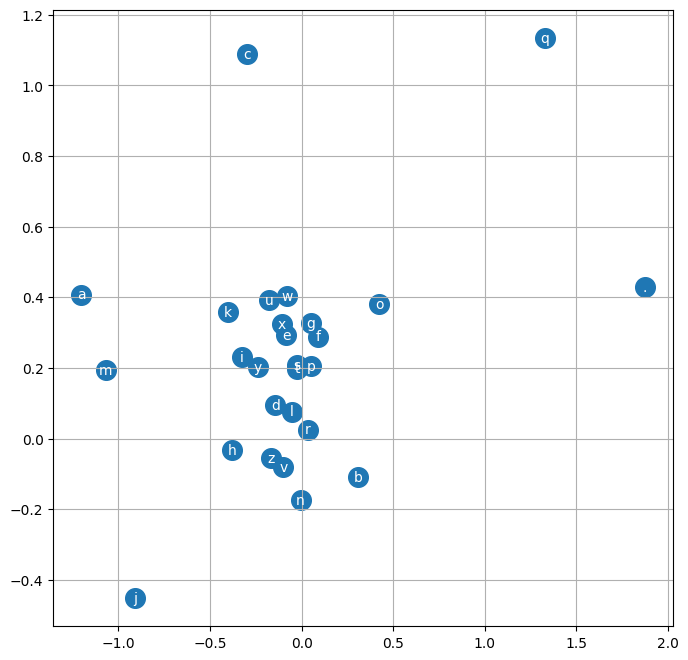

In [154]:
plt.figure(figsize=(8, 8))
plt.scatter(C[:, 0].data, C[:, 1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i, 0].item(), C[i, 1].item(), itos[i], ha='center', va='center', color='white')
plt.grid("minor")

In [157]:
# sample from the model
g = torch.Generator().manual_seed(2147483647)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all '.'
    while True:
        emb = C[torch.tensor([context])] # (1, block_size(3), d(2))
        h = torch.tanh(emb.view(emb.shape[0], -1) @ W1 + b1) # (1, 100)
        logits = h @ W2 + b2 # (1, 27)
        probs = torch.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        if ix == 0:
            break
        context = context[1:] + [ix]
        out.append(ix)
    print(''.join(itos[i] for i in out))

dexza
zomakeraile
kayha
malimittainellayk
katar
samiyah
javer
gotes
moriellanu
kerteda
kaley
maside
enkamerry
folstihaniel
vorilys
dasdri
aneil
pyan
isana
rafenne
